# Experiment No. 02

## AIM
Apply Data Imputation Techniques on the given dataset.

## THEORY

### What is Imputation?
Imputation is the process of replacing **missing data** (null, NaN, or NA values) with substituted values. Real-world datasets often contain missing entries due to data entry errors, sensor failures, survey non-responses, or system glitches. Imputation allows us to retain as much data as possible while still performing meaningful analysis.

### Why is Imputation Important?
- Most machine learning algorithms **cannot handle missing values** directly.
- Dropping rows/columns with missing data can lead to **significant information loss**.
- Proper imputation can **reduce bias** and improve model performance.
- It helps maintain the **statistical power** of the dataset.

---

### Data Imputation Techniques

| # | Technique | Type | Description | Advantages | Disadvantages |
|---|-----------|------|-------------|------------|---------------|
| 1 | **Deletion of rows** | Deletion | Remove rows containing missing values | Simple, no assumptions | Data loss, biased if data is not MCAR |
| 2 | **Mean Imputation** | Statistical | Replace missing numerical values with column mean | Easy, preserves mean | Reduces variance, ignores correlations |
| 3 | **Median Imputation** | Statistical | Replace missing numerical values with column median | Robust to outliers | Reduces variance, ignores relationships |
| 4 | **Mode Imputation** | Statistical | Replace missing categorical values with most frequent category | Simple for categorical data | Can overrepresent dominant category |
| 5 | **Arbitrary Value Imputation** | Value-based | Replace missing values with a chosen constant (e.g., 0, 999) | Flags missing data explicitly | Can distort distribution |
| 6 | **End of Tail Imputation** | Statistical | Replace with values at the extreme end (mean ± 3*std) | Distinguishes imputed values | Creates outliers, distorts distribution |
| 7 | **Random Sample Imputation** | Sampling | Fill missing values with random samples from non-missing data | Preserves original distribution | Adds randomness, not reproducible without seed |
| 8 | **Frequent Category Imputation** | Categorical | Replace missing categories with the most frequent one | Simple, intuitive | Overrepresents one category |
| 9 | **Adding "Missing" Category** | Categorical | Treat missing as a separate category called "Missing" | Retains missingness information | Increases cardinality |
| 10 | **Regression Imputation** | Model-based | Predict missing values using a regression model | Preserves relationships between features | Assumes linear relationship, overfits |

---

### Dataset Used
**Online Retail Dataset** — Contains transactional data from a UK-based online retail store (Dec 2010 – Dec 2011).

### Libraries Used
- `pandas`, `numpy` — Data manipulation
- `missingno` — Missing data visualization
- `seaborn`, `matplotlib` — Statistical plotting
- `plotly` — Interactive visualizations
- `scikit-learn` — Regression imputation

In [10]:
# Install required libraries
!python -m pip install missingno plotly -q

In [11]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
# Load the dataset
df = pd.read_csv('data_online_retail.csv', encoding='latin1')
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [13]:
# Basic dataset info
print("Dataset Info:")
print(df.info())
print("\nDescriptive Statistics:")
df.describe(include='all')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Descriptive Statistics:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


## 1. Analyzing Missing Data

Before imputation, let's understand the extent and pattern of missing values in the dataset.

In [14]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Missing Values Summary:")
print(missing_df)
print(f"\nTotal rows: {len(df)}")
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum()}")

Missing Values Summary:
             Missing Count  Missing %
CustomerID          135080  24.926694
Description           1454   0.268311

Total rows: 541909
Rows with at least one missing value: 135080


In [15]:
# Introduce additional missing values for demonstration purposes
np.random.seed(42)
df_demo = df.copy()

# Add missing values to 'Description' (categorical), 'Quantity' (numerical), 'UnitPrice' (numerical)
mask_desc = np.random.choice(df_demo.index, size=int(len(df_demo) * 0.05), replace=False)
mask_qty = np.random.choice(df_demo.index, size=int(len(df_demo) * 0.08), replace=False)
mask_price = np.random.choice(df_demo.index, size=int(len(df_demo) * 0.06), replace=False)

df_demo.loc[mask_desc, 'Description'] = np.nan
df_demo.loc[mask_qty, 'Quantity'] = np.nan
df_demo.loc[mask_price, 'UnitPrice'] = np.nan

# Convert Quantity and UnitPrice to float to hold NaN
df_demo['Quantity'] = df_demo['Quantity'].astype(float)
df_demo['UnitPrice'] = df_demo['UnitPrice'].astype(float)

print("Missing values after introducing NaNs for demonstration:")
print(df_demo.isnull().sum())
print(f"\nDataset shape: {df_demo.shape}")

Missing values after introducing NaNs for demonstration:
InvoiceNo           0
StockCode           0
Description     28480
Quantity        43352
InvoiceDate         0
UnitPrice       32514
CustomerID     135080
Country             0
dtype: int64

Dataset shape: (541909, 8)


## 2. Visualizing Missing Data

Using **missingno**, **seaborn**, and **plotly** to visualize the pattern of missingness.

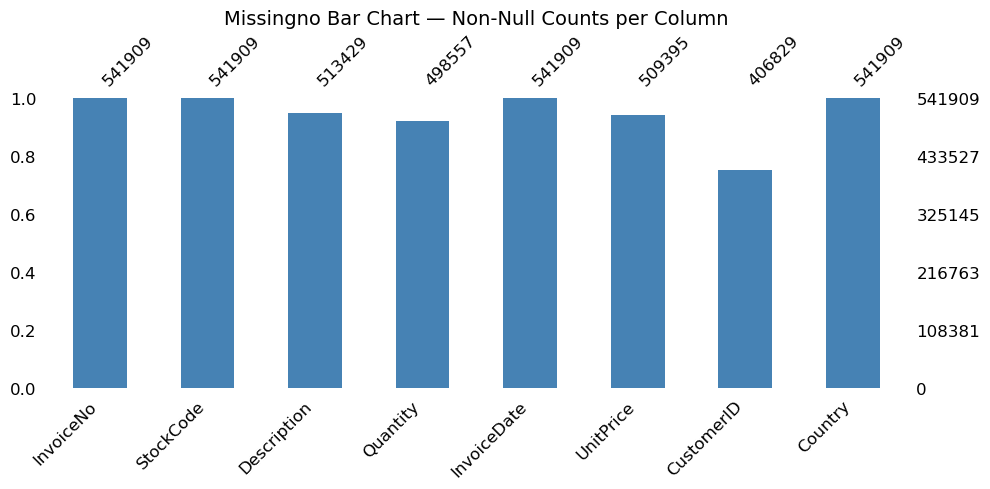

In [16]:
# Missingno Bar Chart — shows non-null counts per column
msno.bar(df_demo, figsize=(10, 5), color='steelblue', fontsize=12)
plt.title("Missingno Bar Chart — Non-Null Counts per Column", fontsize=14)
plt.tight_layout()
plt.show()

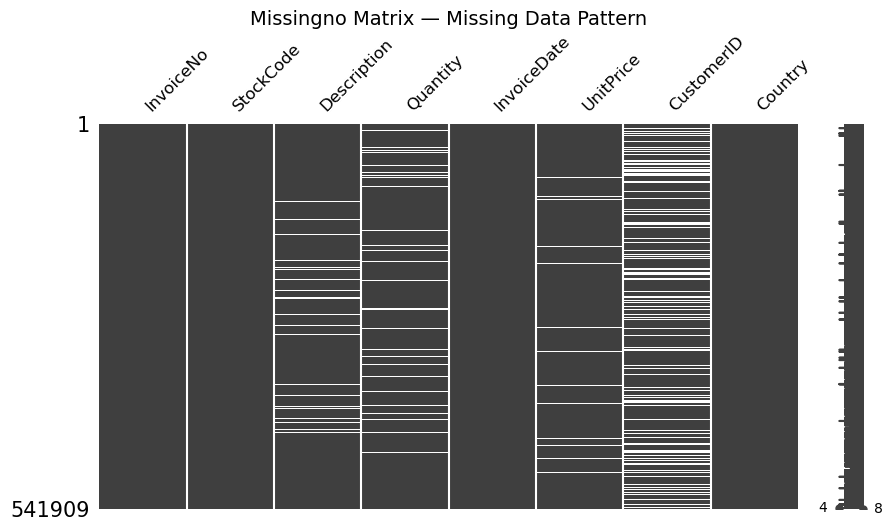

In [17]:
# Missingno Matrix — visualize missing value locations
msno.matrix(df_demo, figsize=(10, 5), fontsize=12)
plt.title("Missingno Matrix — Missing Data Pattern", fontsize=14)
plt.tight_layout()
plt.show()

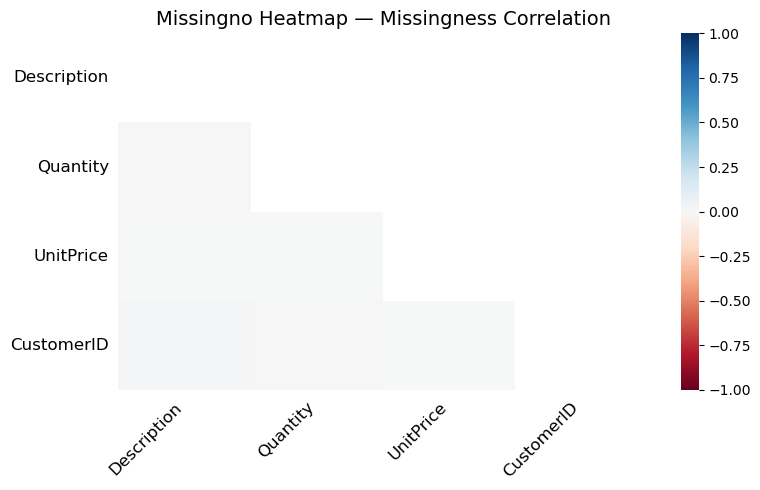

In [18]:
# Missingno Heatmap — correlation of missingness between columns
msno.heatmap(df_demo, figsize=(8, 5), fontsize=12)
plt.title("Missingno Heatmap — Missingness Correlation", fontsize=14)
plt.tight_layout()
plt.show()

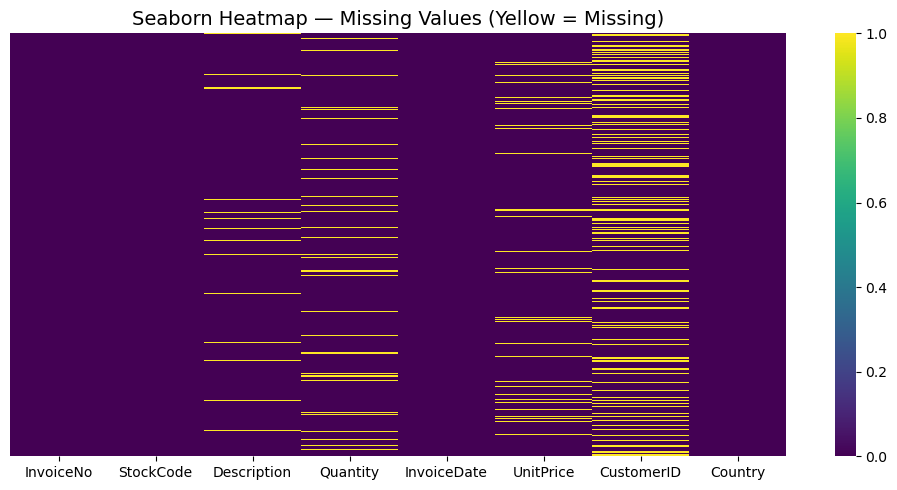

In [19]:
# Seaborn Heatmap — missing values heatmap (True/False)
plt.figure(figsize=(10, 5))
sns.heatmap(df_demo.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Seaborn Heatmap — Missing Values (Yellow = Missing)", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Plotly Bar Chart — Missing values percentage per column
missing_pct_demo = (df_demo.isnull().sum() / len(df_demo)) * 100
fig = px.bar(
    x=missing_pct_demo.index,
    y=missing_pct_demo.values,
    labels={'x': 'Column', 'y': 'Missing %'},
    title='Missing Values Percentage per Column (Plotly)',
    color=missing_pct_demo.values,
    color_continuous_scale='Reds'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

## 3. Data Imputation Techniques

### Technique 1: Deletion of Rows with Missing Data
Remove all rows that contain at least one missing value.

In [21]:
# Technique 1: Deletion of Rows with Missing Data
df_deleted = df_demo.dropna()
print(f"Original shape: {df_demo.shape}")
print(f"After row deletion: {df_deleted.shape}")
print(f"Rows removed: {len(df_demo) - len(df_deleted)} ({((len(df_demo) - len(df_deleted)) / len(df_demo)) * 100:.2f}%)")
print(f"\nMissing values after deletion:\n{df_deleted.isnull().sum()}")

Original shape: (541909, 8)
After row deletion: (334230, 8)
Rows removed: 207679 (38.32%)

Missing values after deletion:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


### Technique 2: Mean Imputation
Replace missing numerical values with the **mean** of the column.

Mean of Quantity: 9.57
Mean of UnitPrice: 4.53

Missing values after Mean Imputation:
Quantity     0
UnitPrice    0
dtype: int64


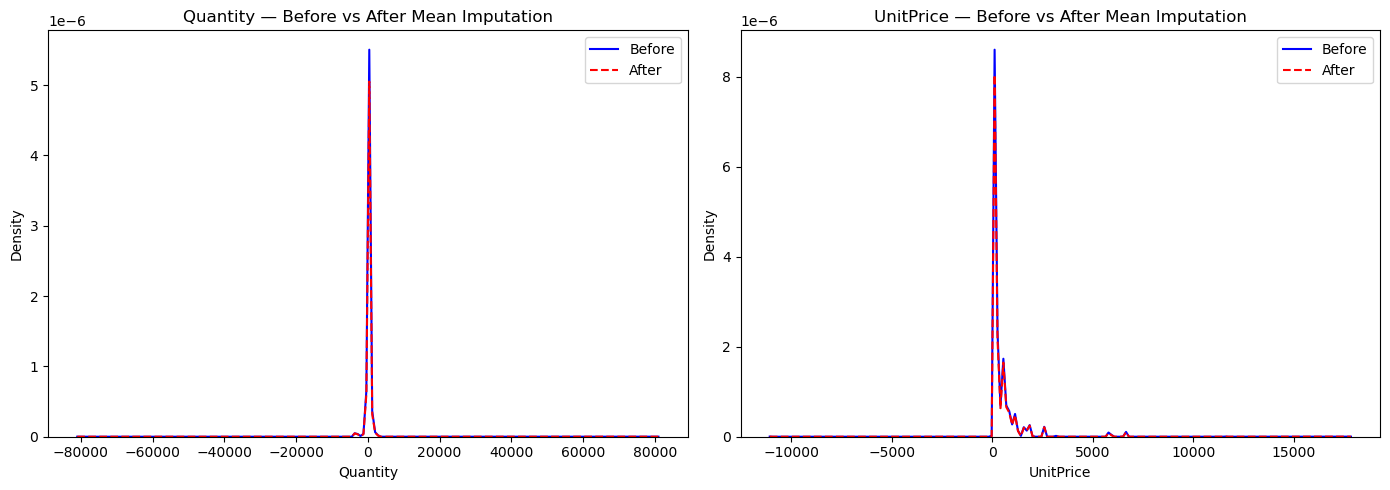

In [22]:
# Technique 2: Mean Imputation
df_mean = df_demo.copy()

mean_qty = df_mean['Quantity'].mean()
mean_price = df_mean['UnitPrice'].mean()

df_mean['Quantity'].fillna(mean_qty, inplace=True)
df_mean['UnitPrice'].fillna(mean_price, inplace=True)

print(f"Mean of Quantity: {mean_qty:.2f}")
print(f"Mean of UnitPrice: {mean_price:.2f}")
print(f"\nMissing values after Mean Imputation:")
print(df_mean[['Quantity', 'UnitPrice']].isnull().sum())

# Visualize the distribution before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Quantity — Before vs After Mean Imputation")
sns.kdeplot(df_demo['Quantity'].dropna(), ax=axes[0], label='Before', color='blue')
sns.kdeplot(df_mean['Quantity'], ax=axes[0], label='After', color='red', linestyle='--')
axes[0].legend()

axes[1].set_title("UnitPrice — Before vs After Mean Imputation")
sns.kdeplot(df_demo['UnitPrice'].dropna(), ax=axes[1], label='Before', color='blue')
sns.kdeplot(df_mean['UnitPrice'], ax=axes[1], label='After', color='red', linestyle='--')
axes[1].legend()
plt.tight_layout()
plt.show()

### Technique 3: Median Imputation
Replace missing numerical values with the **median** of the column. More robust to outliers than mean.

Median of Quantity: 3.00
Median of UnitPrice: 2.08

Missing values after Median Imputation:
Quantity     0
UnitPrice    0
dtype: int64


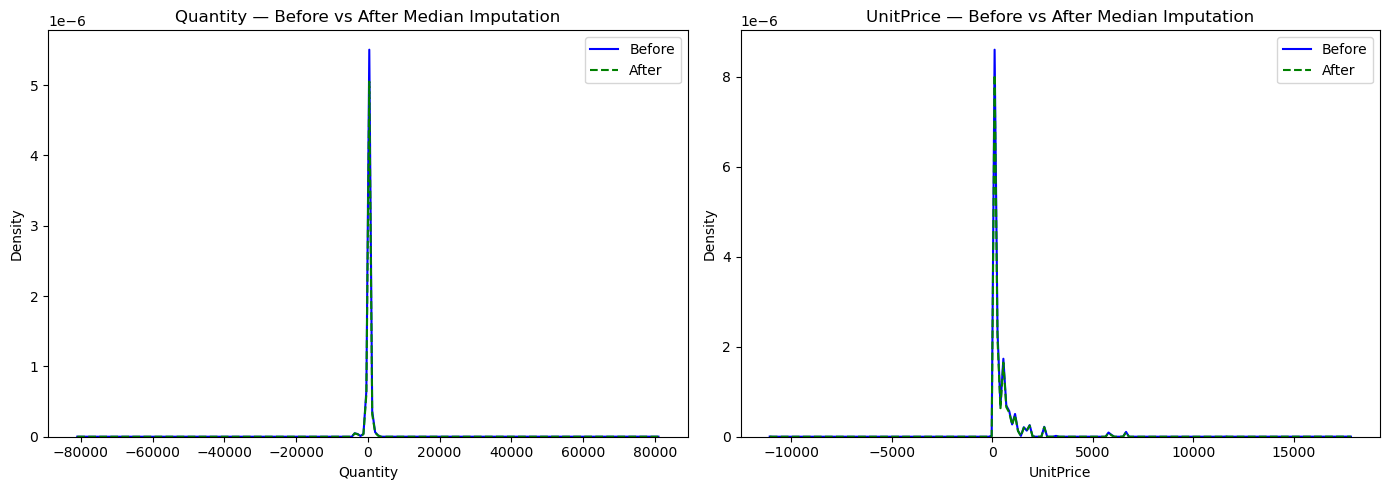

In [23]:
# Technique 3: Median Imputation
df_median = df_demo.copy()

median_qty = df_median['Quantity'].median()
median_price = df_median['UnitPrice'].median()

df_median['Quantity'].fillna(median_qty, inplace=True)
df_median['UnitPrice'].fillna(median_price, inplace=True)

print(f"Median of Quantity: {median_qty:.2f}")
print(f"Median of UnitPrice: {median_price:.2f}")
print(f"\nMissing values after Median Imputation:")
print(df_median[['Quantity', 'UnitPrice']].isnull().sum())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Quantity — Before vs After Median Imputation")
sns.kdeplot(df_demo['Quantity'].dropna(), ax=axes[0], label='Before', color='blue')
sns.kdeplot(df_median['Quantity'], ax=axes[0], label='After', color='green', linestyle='--')
axes[0].legend()

axes[1].set_title("UnitPrice — Before vs After Median Imputation")
sns.kdeplot(df_demo['UnitPrice'].dropna(), ax=axes[1], label='Before', color='blue')
sns.kdeplot(df_median['UnitPrice'], ax=axes[1], label='After', color='green', linestyle='--')
axes[1].legend()
plt.tight_layout()
plt.show()

### Technique 4: Mode Imputation
Replace missing categorical values with the **most frequent** category (mode).

In [24]:
# Technique 4: Mode Imputation (for categorical column — Description)
df_mode = df_demo.copy()

mode_desc = df_mode['Description'].mode()[0]
df_mode['Description'].fillna(mode_desc, inplace=True)

print(f"Mode of Description: '{mode_desc}'")
print(f"\nMissing values in Description after Mode Imputation: {df_mode['Description'].isnull().sum()}")

# Bar chart of top 10 descriptions after mode imputation
top_desc = df_mode['Description'].value_counts().head(10)
fig = px.bar(x=top_desc.index, y=top_desc.values,
             labels={'x': 'Description', 'y': 'Count'},
             title='Top 10 Descriptions After Mode Imputation')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

Mode of Description: 'WHITE HANGING HEART T-LIGHT HOLDER'

Missing values in Description after Mode Imputation: 0


### Technique 5: Arbitrary Value Imputation
Replace missing values with an arbitrary constant (e.g., -999 for numerical, "UNKNOWN" for categorical).

In [25]:
# Technique 5: Arbitrary Value Imputation
df_arb = df_demo.copy()

df_arb['Quantity'].fillna(-999, inplace=True)
df_arb['UnitPrice'].fillna(-999, inplace=True)
df_arb['Description'].fillna('UNKNOWN', inplace=True)

print("Arbitrary values used: -999 (numerical), 'UNKNOWN' (categorical)")
print(f"\nMissing values after Arbitrary Imputation:")
print(df_arb[['Quantity', 'UnitPrice', 'Description']].isnull().sum())

# Show a sample of imputed rows
print("\nSample rows with arbitrary values:")
df_arb[(df_arb['Quantity'] == -999) | (df_arb['UnitPrice'] == -999) | (df_arb['Description'] == 'UNKNOWN')].head()

Arbitrary values used: -999 (numerical), 'UNKNOWN' (categorical)

Missing values after Arbitrary Imputation:
Quantity       0
UnitPrice      0
Description    0
dtype: int64

Sample rows with arbitrary values:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2,536365,84406B,UNKNOWN,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,-999.0,12/1/2010 8:28,1.85,17850.0,United Kingdom
12,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,8.0,12/1/2010 8:34,-999.00,13047.0,United Kingdom
18,536367,21755,LOVE BUILDING BLOCK WORD,-999.0,12/1/2010 8:34,5.95,13047.0,United Kingdom
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24.0,12/1/2010 8:45,-999.00,12583.0,France


### Technique 6: End of Tail Imputation
Replace missing values with extreme values: **mean ± 3 × std** (places imputed values at the tail of the distribution).

End of Tail value for Quantity (mean + 3*std): 688.70
End of Tail value for UnitPrice (mean + 3*std): 240.49

Missing values after End of Tail Imputation:
Quantity     0
UnitPrice    0
dtype: int64


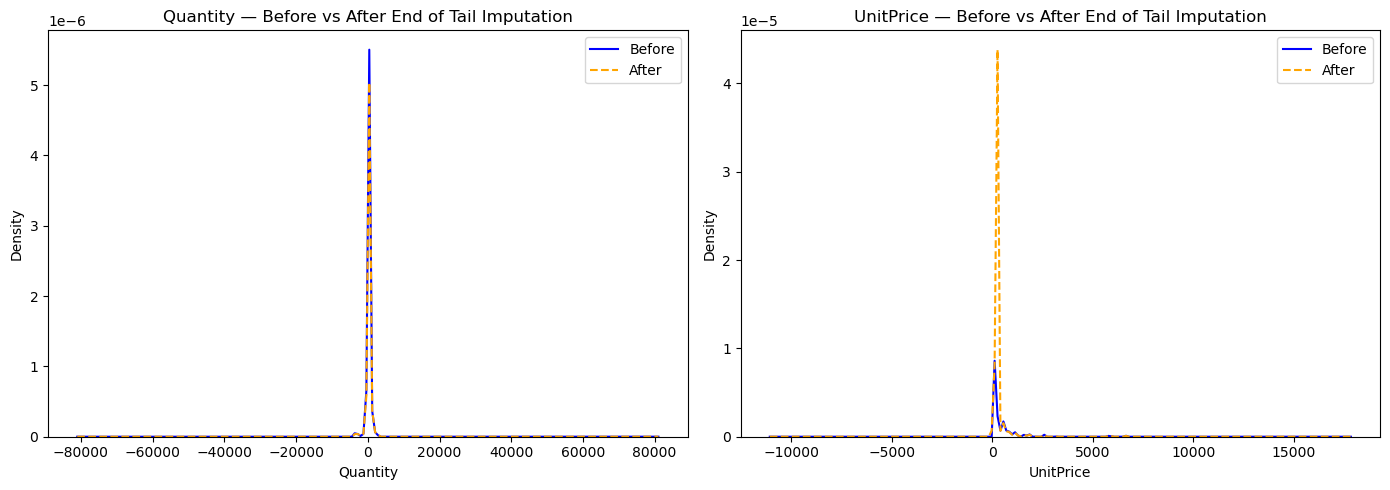

In [26]:
# Technique 6: End of Tail Imputation
df_tail = df_demo.copy()

# Upper tail: mean + 3*std
tail_qty = df_tail['Quantity'].mean() + 3 * df_tail['Quantity'].std()
tail_price = df_tail['UnitPrice'].mean() + 3 * df_tail['UnitPrice'].std()

df_tail['Quantity'].fillna(tail_qty, inplace=True)
df_tail['UnitPrice'].fillna(tail_price, inplace=True)

print(f"End of Tail value for Quantity (mean + 3*std): {tail_qty:.2f}")
print(f"End of Tail value for UnitPrice (mean + 3*std): {tail_price:.2f}")
print(f"\nMissing values after End of Tail Imputation:")
print(df_tail[['Quantity', 'UnitPrice']].isnull().sum())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Quantity — Before vs After End of Tail Imputation")
sns.kdeplot(df_demo['Quantity'].dropna(), ax=axes[0], label='Before', color='blue')
sns.kdeplot(df_tail['Quantity'], ax=axes[0], label='After', color='orange', linestyle='--')
axes[0].legend()

axes[1].set_title("UnitPrice — Before vs After End of Tail Imputation")
sns.kdeplot(df_demo['UnitPrice'].dropna(), ax=axes[1], label='Before', color='blue')
sns.kdeplot(df_tail['UnitPrice'], ax=axes[1], label='After', color='orange', linestyle='--')
axes[1].legend()
plt.tight_layout()
plt.show()

### Technique 7: Random Sample Imputation
Fill missing values by randomly sampling from existing non-null values of the same column.

Missing values after Random Sample Imputation:
Quantity       0
UnitPrice      0
Description    0
dtype: int64


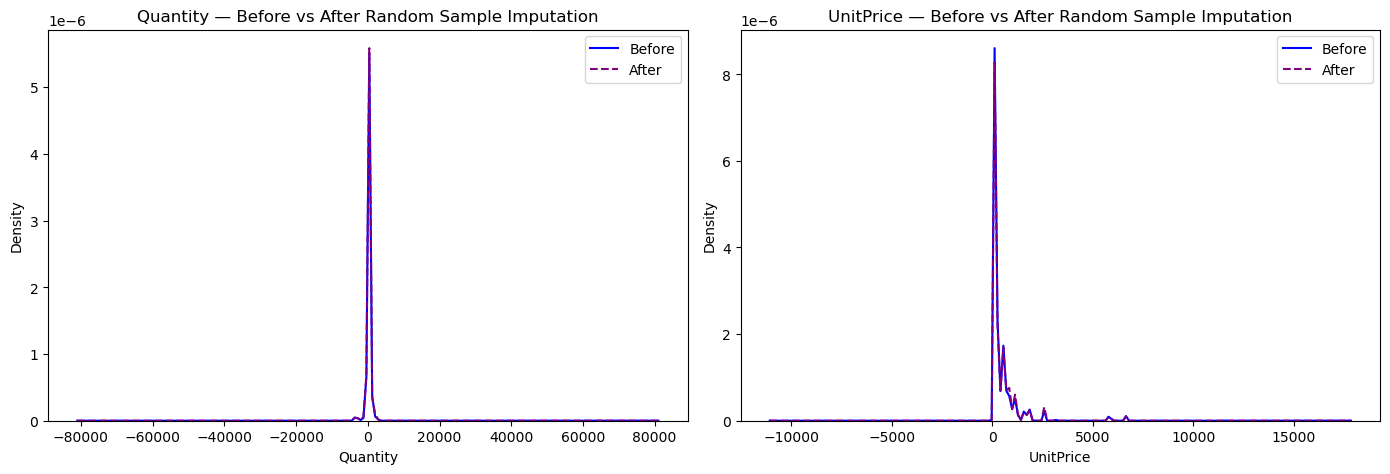

In [27]:
# Technique 7: Random Sample Imputation
df_rand = df_demo.copy()
np.random.seed(42)

def random_sample_impute(series):
    """Fill NaN values with random samples from non-null values."""
    missing_mask = series.isnull()
    n_missing = missing_mask.sum()
    non_null = series.dropna()
    random_samples = non_null.sample(n_missing, replace=True, random_state=42).values
    series_copy = series.copy()
    series_copy[missing_mask] = random_samples
    return series_copy

df_rand['Quantity'] = random_sample_impute(df_rand['Quantity'])
df_rand['UnitPrice'] = random_sample_impute(df_rand['UnitPrice'])
df_rand['Description'] = random_sample_impute(df_rand['Description'])

print("Missing values after Random Sample Imputation:")
print(df_rand[['Quantity', 'UnitPrice', 'Description']].isnull().sum())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Quantity — Before vs After Random Sample Imputation")
sns.kdeplot(df_demo['Quantity'].dropna(), ax=axes[0], label='Before', color='blue')
sns.kdeplot(df_rand['Quantity'], ax=axes[0], label='After', color='purple', linestyle='--')
axes[0].legend()

axes[1].set_title("UnitPrice — Before vs After Random Sample Imputation")
sns.kdeplot(df_demo['UnitPrice'].dropna(), ax=axes[1], label='Before', color='blue')
sns.kdeplot(df_rand['UnitPrice'], ax=axes[1], label='After', color='purple', linestyle='--')
axes[1].legend()
plt.tight_layout()
plt.show()

### Technique 8: Frequent Category Imputation
Replace missing categorical values with the **most frequent** category (similar to Mode for categorical data).

In [28]:
# Technique 8: Frequent Category Imputation (for Country column)
df_freq = df_demo.copy()

# Introduce some missing values in Country for demonstration
np.random.seed(10)
mask_country = np.random.choice(df_freq.index, size=int(len(df_freq) * 0.04), replace=False)
df_freq.loc[mask_country, 'Country'] = np.nan

freq_country = df_freq['Country'].mode()[0]
print(f"Most frequent Country: '{freq_country}'")
print(f"Missing Country values before: {df_freq['Country'].isnull().sum()}")

df_freq['Country'].fillna(freq_country, inplace=True)
print(f"Missing Country values after: {df_freq['Country'].isnull().sum()}")

# Plotly pie chart for top countries
top_countries = df_freq['Country'].value_counts().head(8)
fig = px.pie(values=top_countries.values, names=top_countries.index,
             title='Country Distribution After Frequent Category Imputation')
fig.show()

Most frequent Country: 'United Kingdom'
Missing Country values before: 21676
Missing Country values after: 0


### Technique 9: Adding a New Category as "Missing"
Instead of imputing, treat the missing value as its own category — explicitly labeled **"Missing"**.

Missing values after adding 'Missing' category:
Description    0
CustomerID     0
dtype: int64

Rows with Description = 'Missing': 28481
Rows with CustomerID = 'Missing': 135080


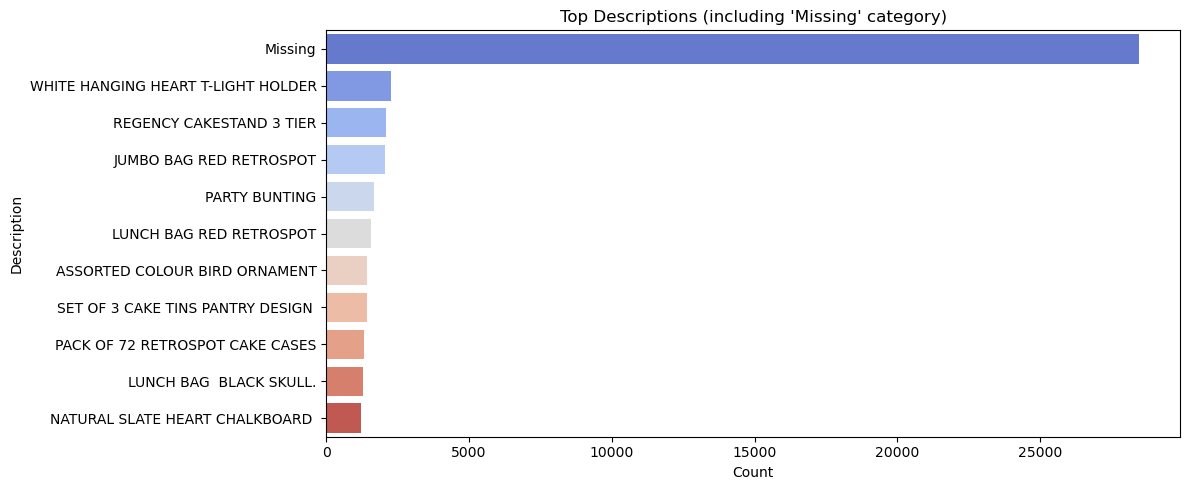

In [29]:
# Technique 9: Adding a New "Missing" Category
df_missing_cat = df_demo.copy()

df_missing_cat['Description'].fillna('Missing', inplace=True)
df_missing_cat['CustomerID'] = df_demo['CustomerID'].astype(str)
df_missing_cat['CustomerID'].replace('nan', 'Missing', inplace=True)

print("Missing values after adding 'Missing' category:")
print(df_missing_cat[['Description', 'CustomerID']].isnull().sum())

# Count of "Missing" category
print(f"\nRows with Description = 'Missing': {(df_missing_cat['Description'] == 'Missing').sum()}")
print(f"Rows with CustomerID = 'Missing': {(df_missing_cat['CustomerID'] == 'Missing').sum()}")

# Visualization
desc_counts = df_missing_cat['Description'].value_counts().head(11)
plt.figure(figsize=(12, 5))
sns.barplot(x=desc_counts.values, y=desc_counts.index, palette='coolwarm')
plt.title("Top Descriptions (including 'Missing' category)")
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### Technique 10: Regression Imputation
Use a **Linear Regression** model to predict missing values based on other features.

Training rows (UnitPrice known): 509395
Rows to predict (UnitPrice missing): 32514

Regression Coefficients — Intercept: 4.5362, Slope: -0.0005
Missing UnitPrice after Regression Imputation: 0


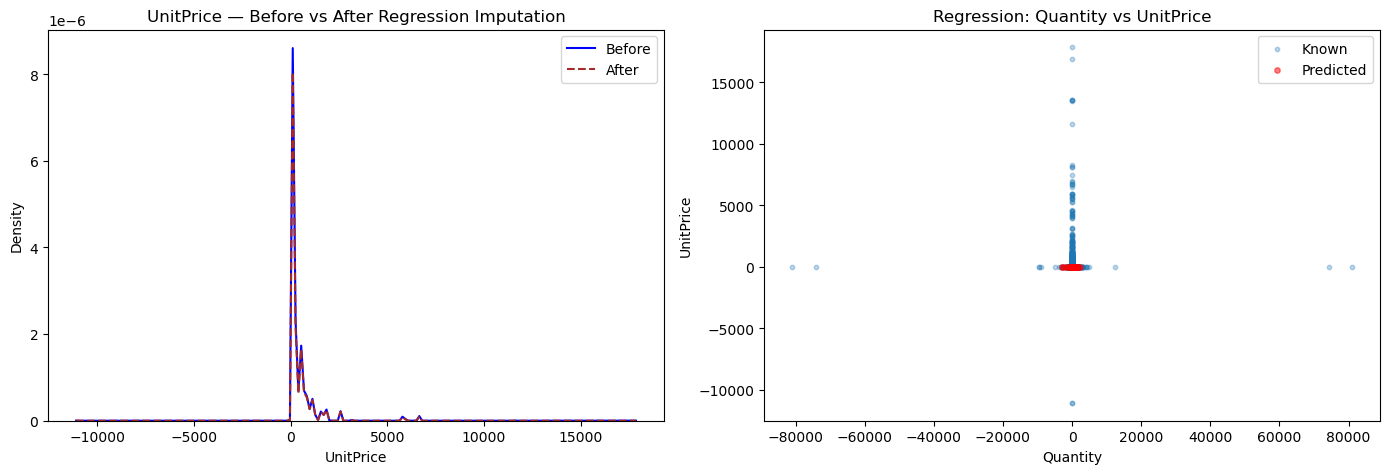

In [30]:
# Technique 10: Regression Imputation (Predict UnitPrice from Quantity)
df_reg = df_demo.copy()

# First, impute Quantity with median so we can use it as predictor
df_reg['Quantity'].fillna(df_reg['Quantity'].median(), inplace=True)

# Separate rows where UnitPrice is known vs missing
train = df_reg[df_reg['UnitPrice'].notna()]
test = df_reg[df_reg['UnitPrice'].isna()]

print(f"Training rows (UnitPrice known): {len(train)}")
print(f"Rows to predict (UnitPrice missing): {len(test)}")

# Fit Linear Regression: UnitPrice ~ Quantity
model = LinearRegression()
model.fit(train[['Quantity']], train['UnitPrice'])

# Predict missing UnitPrice
predicted = model.predict(test[['Quantity']])
df_reg.loc[df_reg['UnitPrice'].isna(), 'UnitPrice'] = predicted

print(f"\nRegression Coefficients — Intercept: {model.intercept_:.4f}, Slope: {model.coef_[0]:.4f}")
print(f"Missing UnitPrice after Regression Imputation: {df_reg['UnitPrice'].isnull().sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("UnitPrice — Before vs After Regression Imputation")
sns.kdeplot(df_demo['UnitPrice'].dropna(), ax=axes[0], label='Before', color='blue')
sns.kdeplot(df_reg['UnitPrice'], ax=axes[0], label='After', color='brown', linestyle='--')
axes[0].legend()

axes[1].scatter(train['Quantity'], train['UnitPrice'], alpha=0.3, s=10, label='Known')
axes[1].scatter(test['Quantity'], predicted, color='red', alpha=0.5, s=15, label='Predicted')
axes[1].set_title("Regression: Quantity vs UnitPrice")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("UnitPrice")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Comparison of Imputation Techniques

In [31]:
# Comparison: Effect of imputation techniques on UnitPrice statistics
original_stats = df_demo['UnitPrice'].dropna().describe()

comparison = pd.DataFrame({
    'Original (no NaN)': original_stats,
    'Mean Imputed': df_mean['UnitPrice'].describe(),
    'Median Imputed': df_median['UnitPrice'].describe(),
    'End of Tail': df_tail['UnitPrice'].describe(),
    'Random Sample': df_rand['UnitPrice'].describe(),
    'Regression': df_reg['UnitPrice'].describe()
})
print("UnitPrice Statistics — Comparison Across Techniques:\n")
comparison

UnitPrice Statistics — Comparison Across Techniques:



,Original (no NaN),Mean Imputed,Median Imputed,End of Tail,Random Sample,Regression
count,509395.000000,541909.000000,541909.000000,541909.000000,541909.000000,541909.000000
mean,4.531997,4.531997,4.384880,18.689374,4.528041,4.531994
std,78.653397,76.257333,76.259557,94.632619,77.163017,76.257333
min,-11062.060000,-11062.060000,-11062.060000,-11062.060000,-11062.060000,-11062.060000
25%,1.250000,1.250000,1.250000,1.250000,1.250000,1.250000
50%,2.080000,2.100000,2.080000,2.100000,2.080000,2.100000
75%,4.130000,4.531997,4.130000,4.950000,4.130000,4.526913
max,17836.460000,17836.460000,17836.460000,17836.460000,17836.460000,17836.460000


In [32]:
# Plotly grouped bar chart — comparing mean and std across techniques
techniques = ['Original', 'Mean', 'Median', 'End of Tail', 'Random Sample', 'Regression']
means = [
    df_demo['UnitPrice'].dropna().mean(),
    df_mean['UnitPrice'].mean(),
    df_median['UnitPrice'].mean(),
    df_tail['UnitPrice'].mean(),
    df_rand['UnitPrice'].mean(),
    df_reg['UnitPrice'].mean()
]
stds = [
    df_demo['UnitPrice'].dropna().std(),
    df_mean['UnitPrice'].std(),
    df_median['UnitPrice'].std(),
    df_tail['UnitPrice'].std(),
    df_rand['UnitPrice'].std(),
    df_reg['UnitPrice'].std()
]

fig = go.Figure(data=[
    go.Bar(name='Mean', x=techniques, y=means, marker_color='steelblue'),
    go.Bar(name='Std Dev', x=techniques, y=stds, marker_color='salmon')
])
fig.update_layout(
    barmode='group',
    title='UnitPrice — Mean & Std Comparison Across Imputation Techniques',
    yaxis_title='Value',
    xaxis_title='Technique'
)
fig.show()

## Conclusion

In this experiment, we applied **10 different data imputation techniques** on the Online Retail dataset:

1. **Row Deletion** — Simplest but causes significant data loss; only suitable when missing data is minimal and MCAR.
2. **Mean Imputation** — Preserves the original mean but reduces variance; not suitable when outliers are present.
3. **Median Imputation** — More robust to outliers than mean; preferred for skewed distributions.
4. **Mode Imputation** — Effective for categorical features; may overrepresent the dominant category.
5. **Arbitrary Value Imputation** — Clearly flags missing data but can distort distributions if values are unrealistic.
6. **End of Tail Imputation** — Pushes imputed values to extremes; useful when missingness itself is informative.
7. **Random Sample Imputation** — Best preserves the original distribution; introduces randomness.
8. **Frequent Category Imputation** — Simple for categorical data; biases toward the most common class.
9. **"Missing" Category** — Retains missingness as information; increases feature cardinality.
10. **Regression Imputation** — Leverages feature relationships; assumes linearity and can overfit.

**Key Takeaway:** No single imputation method is universally best — the choice depends on the data distribution, the mechanism of missingness (MCAR, MAR, MNAR), and the downstream analysis requirements. Visualizing missing patterns before imputation is crucial for making informed decisions.